### Feature Engineering

Machine learning models require structured features that capture
temporal patterns in the data.

In this notebook we create several feature types commonly used in
time-series forecasting:

• lag features (previous demand values)  
• rolling statistics (moving averages and volatility)  
• momentum indicators  
• cyclical time encodings  

These features allow machine learning models to capture
seasonality, trends, and demand dynamics.

In [1]:
"""
Import required libraries for feature engineering.
"""

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
"""
Load restaurant demand dataset.
"""

df = pd.read_csv("../data/restaurant_orders.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,temperature,rain,holiday,promotion,local_event,tourism_season,festival_week,economic_slowdown,base_orders,total_orders
0,2016-01-01,Friday,4,1,2016,53,0,1.00,1.003443,1.000000,21.662276,0,0,0,0,0,0,0,150.516401,122
1,2016-01-02,Saturday,5,1,2016,53,1,1.25,1.006884,1.000086,19.929423,0,0,0,0,0,0,0,188.806968,173
2,2016-01-03,Sunday,6,1,2016,53,1,1.25,1.010324,1.000171,22.459262,1,0,0,1,0,0,0,189.468164,229
3,2016-01-04,Monday,0,1,2016,1,0,1.00,1.013760,1.000257,25.257114,0,0,0,0,0,0,0,152.103117,173
4,2016-01-05,Tuesday,1,1,2016,1,0,1.00,1.017193,1.000342,20.157188,1,0,0,0,0,0,0,152.631179,168


In [3]:
"""
Create additional calendar-based features.
"""

df["day_of_year"] = df["date"].dt.dayofyear
df["quarter"] = df["date"].dt.quarter

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,...,holiday,promotion,local_event,tourism_season,festival_week,economic_slowdown,base_orders,total_orders,day_of_year,quarter
0,2016-01-01,Friday,4,1,2016,53,0,1.00,1.003443,1.000000,...,0,0,0,0,0,0,150.516401,122,1,1
1,2016-01-02,Saturday,5,1,2016,53,1,1.25,1.006884,1.000086,...,0,0,0,0,0,0,188.806968,173,2,1
2,2016-01-03,Sunday,6,1,2016,53,1,1.25,1.010324,1.000171,...,0,0,1,0,0,0,189.468164,229,3,1
3,2016-01-04,Monday,0,1,2016,1,0,1.00,1.013760,1.000257,...,0,0,0,0,0,0,152.103117,173,4,1
4,2016-01-05,Tuesday,1,1,2016,1,0,1.00,1.017193,1.000342,...,0,0,0,0,0,0,152.631179,168,5,1


In [4]:
"""
Create lag features representing previous demand values.
"""

lags = [1, 7, 14, 30]

for lag in lags:

    df[f"orders_lag_{lag}"] = df["total_orders"].shift(lag)

In [5]:
"""
Create rolling averages capturing short and medium-term demand trends.
"""

windows = [7, 14, 30]

for window in windows:

    df[f"rolling_mean_{window}"] = (
        df["total_orders"]
        .shift(1)
        .rolling(window)
        .mean()
    )

In [6]:
"""
Create rolling standard deviation features to capture demand volatility.
"""

for window in [7, 14]:

    df[f"rolling_std_{window}"] = (
        df["total_orders"]
        .shift(1)
        .rolling(window)
        .std()
    )

In [7]:
"""
Create momentum features representing demand acceleration.
"""

df["momentum_1_7"] = df["orders_lag_1"] - df["orders_lag_7"]

df["momentum_7_14"] = df["orders_lag_7"] - df["orders_lag_14"]

In [8]:
"""
Encode cyclical time features using sine and cosine transformations.
"""

df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

In [9]:
"""
Remove rows with missing values created by lag features.
"""

df = df.dropna()

df.shape

(2892, 37)

In [10]:
"""
Inspect final feature set.
"""

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (2892, 37)


,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,...,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_14,momentum_1_7,momentum_7_14,dow_sin,dow_cos,month_sin,month_cos
30,2016-01-31,Sunday,6,1,2016,4,1,1.25,1.101734,1.002568,...,171.285714,171.700000,24.533747,27.691789,38.0,-29.0,-0.781831,0.623490,0.500000,0.866025
31,2016-02-01,Monday,0,2,2016,5,0,1.00,1.104683,1.002653,...,171.571429,174.933333,28.641462,28.193601,72.0,4.0,0.000000,1.000000,0.866025,0.500000
32,2016-02-02,Tuesday,1,2,2016,5,0,1.00,1.107601,1.002739,...,171.642857,173.966667,29.319261,28.116809,-30.0,23.0,0.781831,0.623490,0.866025,0.500000
33,2016-02-03,Wednesday,2,2,2016,5,0,1.00,1.110487,1.002824,...,172.785714,171.900000,29.854409,27.532299,-2.0,2.0,0.974928,-0.222521,0.866025,0.500000
34,2016-02-04,Thursday,3,2,2016,5,0,1.00,1.113340,1.002910,...,173.142857,171.866667,29.631065,27.483861,5.0,13.0,0.433884,-0.900969,0.866025,0.500000


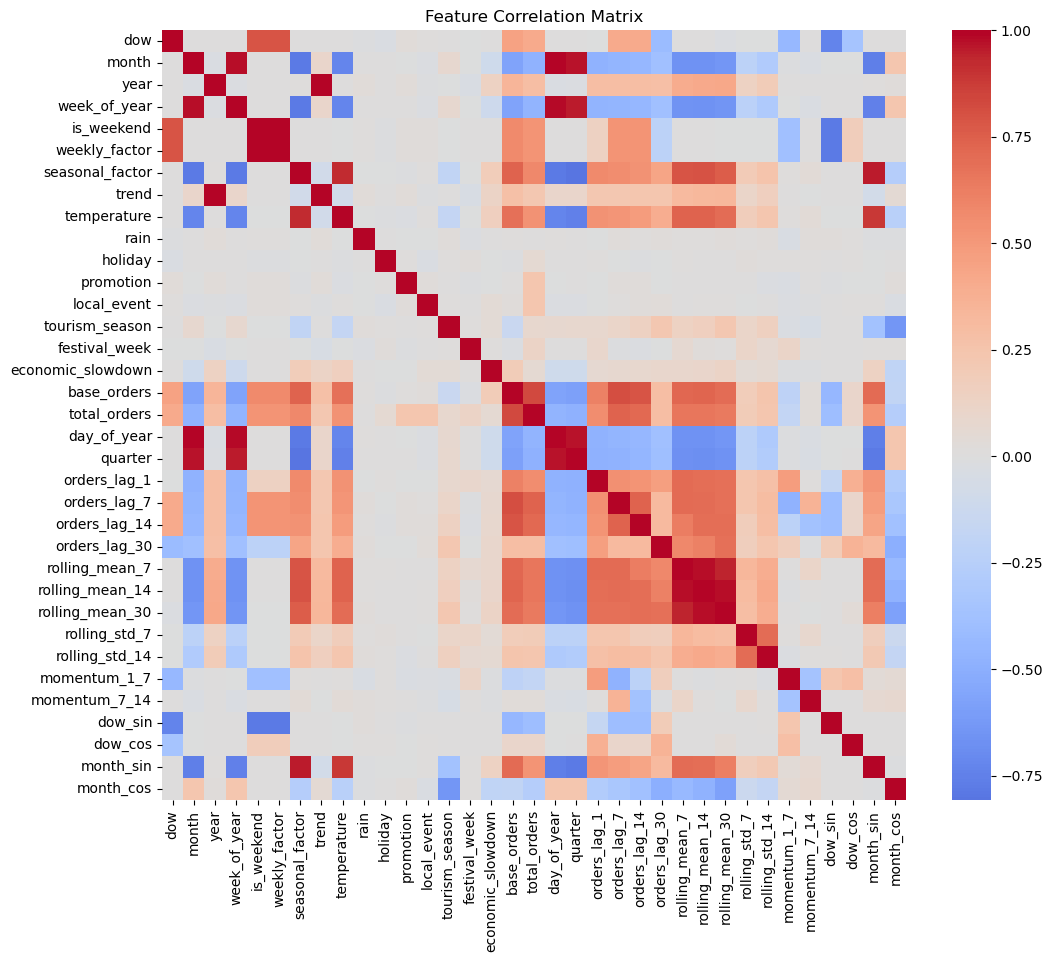

In [11]:
"""
Analyze correlation between engineered features and demand.
"""

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [12]:
"""
Save dataset with engineered features.
"""

df.to_csv("../data/restaurant_features.csv", index=False)

print("Feature dataset saved successfully.")

Feature dataset saved successfully.
